In [1]:
# ================== TASK 0: SETUP ==================
import os, time, zipfile, urllib.request, random
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib as mpl
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (accuracy_score, precision_score, recall_score,
                              f1_score, confusion_matrix)
import tensorflow as tf
from tensorflow.keras import layers, models, optimizers

SEED = 42
np.random.seed(SEED); random.seed(SEED); tf.random.set_seed(SEED)

PLOT_DIR = "Experiment6_Plots"
os.makedirs(PLOT_DIR, exist_ok=True)

# Lab-wide plot formatting: 200 DPI, bold axis labels, bold legend text
mpl.rcParams["savefig.dpi"] = 200
mpl.rcParams["figure.dpi"] = 100
mpl.rcParams["font.weight"] = "bold"
mpl.rcParams["axes.labelweight"] = "bold"
mpl.rcParams["axes.titleweight"] = "bold"

def style_bold_legend(ax):
    leg = ax.get_legend()
    if leg is not None:
        for t in leg.get_texts():
            t.set_fontweight("bold")

def savefig(name):
    path = os.path.join(PLOT_DIR, name)
    plt.tight_layout()
    plt.savefig(path, dpi=200)
    plt.show()
    print("Saved:", path)

In [2]:
# ================== TASK 1: DOWNLOAD DATASET ==================
UCI_URL = "https://archive.ics.uci.edu/static/public/240/human+activity+recognition+using+smartphones.zip"
ZIP_PATH = "har.zip"
DATA_DIR = "UCI_HAR_Dataset"

if not os.path.exists(DATA_DIR):
    urllib.request.urlretrieve(UCI_URL, ZIP_PATH)
    with zipfile.ZipFile(ZIP_PATH, "r") as z:
        z.extractall(".")
    inner = [f for f in os.listdir(".") if f.lower().endswith(".zip") and f != ZIP_PATH]
    for f in inner:
        with zipfile.ZipFile(f, "r") as z:
            z.extractall(".")
    if os.path.isdir("UCI HAR Dataset") and not os.path.isdir(DATA_DIR):
        os.rename("UCI HAR Dataset", DATA_DIR)

print("Dataset ready at:", DATA_DIR)

Dataset ready at: UCI_HAR_Dataset


In [3]:
# ================== TASK 2: LOAD RAW SIGNALS (TRAIN PARTITION ONLY) ==================
SIGNALS = [
    "body_acc_x", "body_acc_y", "body_acc_z",
    "body_gyro_x", "body_gyro_y", "body_gyro_z",
    "total_acc_x", "total_acc_y", "total_acc_z",
]
ACTIVITIES = {1: "WALKING", 2: "WALKING_UPSTAIRS", 3: "WALKING_DOWNSTAIRS",
              4: "SITTING", 5: "STANDING", 6: "LAYING"}

def load_split(split):
    base = os.path.join(DATA_DIR, split, "Inertial Signals")
    channels = []
    for sig in SIGNALS:
        fpath = os.path.join(base, f"{sig}_{split}.txt")
        channels.append(np.loadtxt(fpath))          # (N, 128)
    X = np.stack(channels, axis=-1)                  # (N, 128, 9)
    y = np.loadtxt(os.path.join(DATA_DIR, split, f"y_{split}.txt")).astype(int)
    return X, y

# The lab's "recommended subset" is drawn from the TRAINING partition only
X_train_full, y_train_full = load_split("train")
y_train_full = y_train_full - 1   # 0-indexed labels

print("Full training partition (raw):", X_train_full.shape)

Full training partition (raw): (7352, 128, 9)


In [4]:
# ================== TASK 3: PREPROCESSING ==================
NUM_CLASSES = 6
LAB_SUBSET_SIZE = 2000   # within the recommended 1500-3000 window range

# Step 1-3: take the FIRST LAB_SUBSET_SIZE windows in original file order (no shuffling)
X_sub = X_train_full[:LAB_SUBSET_SIZE]
y_sub = y_train_full[:LAB_SUBSET_SIZE]

# Step 4 + "verify class distribution" (Section 5, step 7)
class_counts = np.bincount(y_sub, minlength=NUM_CLASSES)
print(f"Class distribution in the first {LAB_SUBSET_SIZE} training windows:")
for c in range(NUM_CLASSES):
    print(f"  {ACTIVITIES[c + 1]:20s}: {class_counts[c]}")

# Step 6: create training / validation / test sets (70 / 15 / 15), shuffled only here
X_train, X_tmp, y_train, y_tmp = train_test_split(
    X_sub, y_sub, test_size=0.30, stratify=y_sub, random_state=SEED)
X_val, X_test, y_val, y_test = train_test_split(
    X_tmp, y_tmp, test_size=0.50, stratify=y_tmp, random_state=SEED)

# Step 5: normalize using statistics from the TRAINING data only
scaler = StandardScaler()
N, T, F = X_train.shape
scaler.fit(X_train.reshape(-1, F))

def normalize(X):
    n, t, f = X.shape
    return scaler.transform(X.reshape(-1, f)).reshape(n, t, f)

X_train, X_val, X_test = normalize(X_train), normalize(X_val), normalize(X_test)

# Expected preprocessing output (Section 5)
print("\nInput tensor shape:")
print(f"  Training   : {X_train.shape}")
print(f"  Validation : {X_val.shape}")
print(f"  Testing    : {X_test.shape}")
print(f"Number of classes: {NUM_CLASSES}")
print(f"Number of features per time step: {F}")
print(f"Sequence length: {T}")
print("Class distribution (train):", np.bincount(y_train))
print("Class distribution (val):  ", np.bincount(y_val))
print("Class distribution (test): ", np.bincount(y_test))

Class distribution in the first 2000 training windows:
  WALKING             : 390
  WALKING_UPSTAIRS    : 302
  WALKING_DOWNSTAIRS  : 278
  SITTING             : 318
  STANDING            : 355
  LAYING              : 357

Input tensor shape:
  Training   : (1400, 128, 9)
  Validation : (300, 128, 9)
  Testing    : (300, 128, 9)
Number of classes: 6
Number of features per time step: 9
Sequence length: 128
Class distribution (train): [273 211 195 223 248 250]
Class distribution (val):   [59 46 41 47 53 54]
Class distribution (test):  [58 45 42 48 54 53]


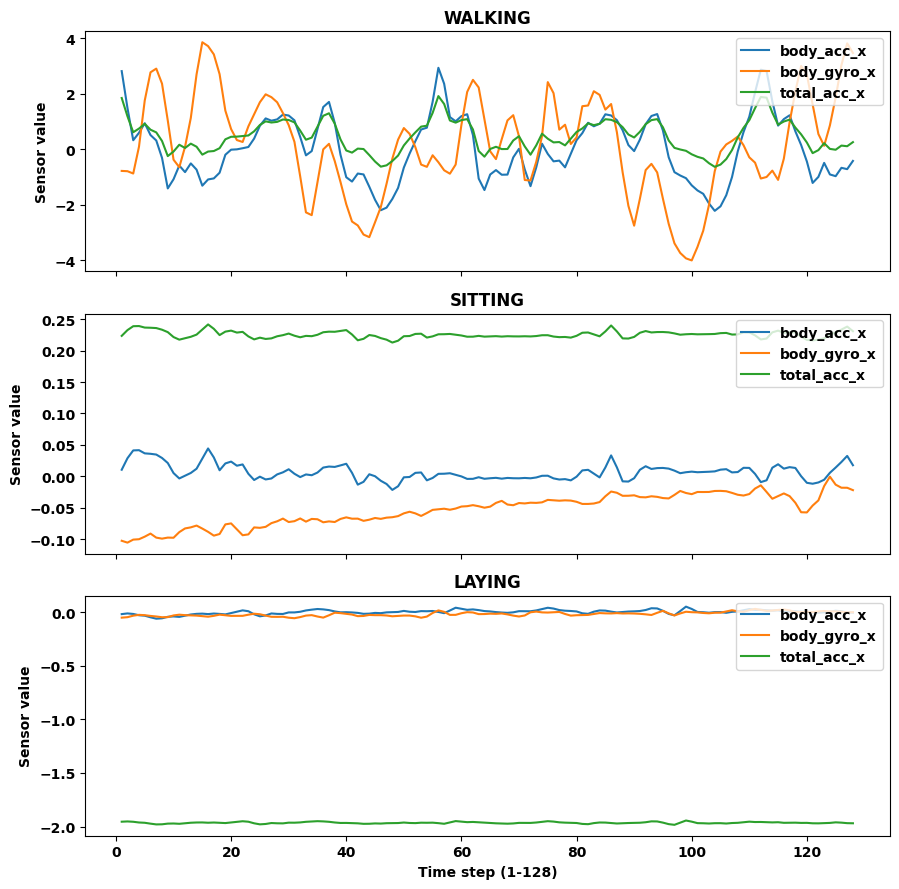

Saved: Experiment6_Plots/plot1_sensor_signal_vs_time.png


In [5]:
# ================== TASK 4: PLOT 1 - SENSOR SIGNAL VS TIME ==================
chosen_classes = [0, 3, 5]   # WALKING, SITTING, LAYING (0-indexed)
chosen_channels = [0, 3, 6]  # body_acc_x, body_gyro_x, total_acc_x

fig, axes = plt.subplots(len(chosen_classes), 1, figsize=(9, 9), sharex=True)
for ax, c in zip(axes, chosen_classes):
    sample_idx = np.where(y_train == c)[0][0]
    for ch in chosen_channels:
        ax.plot(range(1, T + 1), X_train[sample_idx, :, ch], label=SIGNALS[ch])
    ax.set_title(ACTIVITIES[c + 1], fontweight="bold")
    ax.set_ylabel("Sensor value", fontweight="bold")
    ax.legend(loc="upper right")
    style_bold_legend(ax)
axes[-1].set_xlabel("Time step (1-128)", fontweight="bold")
savefig("plot1_sensor_signal_vs_time.png")

In [6]:
# ================== TASK 5: BPTT MANUAL CALCULATION ==================
x1, x2, x3 = 0.5, 0.7, 0.2
h0 = 0.0
Wx, Wh, b = 0.5, 0.8, 0.1

# Program calculation
h1_prog = np.tanh(Wx * x1 + Wh * h0 + b)
h2_prog = np.tanh(Wx * x2 + Wh * h1_prog + b)
h3_prog = np.tanh(Wx * x3 + Wh * h2_prog + b)

# Manual calculation
h1_manual = np.tanh(0.5 * 0.5 + 0.8 * 0 + 0.1)
h2_manual = np.tanh(0.5 * 0.7 + 0.8 * h1_manual + 0.1)
h3_manual = np.tanh(0.5 * 0.2 + 0.8 * h2_manual + 0.1)

print("BPTT Numerical Exercise")
print("-" * 45)

print(f"h1 - Manual  : {h1_manual:.6f}")
print(f"h1 - Program : {h1_prog:.6f}")
print(f"Difference   : {abs(h1_manual - h1_prog):.10f}\n")

print(f"h2 - Manual  : {h2_manual:.6f}")
print(f"h2 - Program : {h2_prog:.6f}")
print(f"Difference   : {abs(h2_manual - h2_prog):.10f}\n")

print(f"h3 - Manual  : {h3_manual:.6f}")
print(f"h3 - Program : {h3_prog:.6f}")
print(f"Difference   : {abs(h3_manual - h3_prog):.10f}")


BPTT Numerical Exercise
---------------------------------------------
h1 - Manual  : 0.336376
h1 - Program : 0.336376
Difference   : 0.0000000000

h2 - Manual  : 0.616352
h2 - Program : 0.616352
Difference   : 0.0000000000

h3 - Manual  : 0.599958
h3 - Program : 0.599958
Difference   : 0.0000000000


In [7]:
# ================== TASK 6: MODEL BUILDER ==================
# Same architecture, optimizer, batch size and evaluation protocol for all three,
# so the only thing that changes is the recurrent layer type (Section 12 table).
def build_model(cell_type, units=32, T=T, F=F, num_classes=NUM_CLASSES):
    if cell_type == "RNN":
        rec = layers.SimpleRNN(units)
    elif cell_type == "LSTM":
        rec = layers.LSTM(units)
    elif cell_type == "GRU":
        rec = layers.GRU(units)
    else:
        raise ValueError(cell_type)

    model = models.Sequential([
        layers.Input(shape=(T, F)),
        rec,
        layers.Dropout(0.2),
        layers.Dense(16, activation="relu"),
        layers.Dense(num_classes, activation="softmax"),
    ])
    model.compile(optimizer=optimizers.Adam(learning_rate=1e-3),
                  loss="sparse_categorical_crossentropy",
                  metrics=["accuracy"])
    return model

print(build_model("LSTM").summary())

print(pd.DataFrame({
    "Model": ["RNN", "LSTM", "GRU"],
    "Recurrent Layer": ["SimpleRNN", "LSTM", "GRU"],
    "Units": [32, 32, 32],
    "Output Classes": [6, 6, 6],
}).to_string(index=False))

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm (LSTM)                     │ (None, 32)             │         5,376 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 16)             │           528 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 6)              │           102 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 6,006 (23.46 KB)

 Trainable params: 6,006 (23.46 KB)

 Non-trainable params: 0 (0.00 B)

None
Model Recurrent Layer  Units  Output Classes
  RNN       SimpleRNN     32               6
 LSTM            LSTM     32               6
  GRU             GRU     32               6


In [8]:
# ================== TASK 7: TRAIN THE THREE MODELS ==================
EPOCHS = 30
BATCH = 32

histories, models_dict, train_times, param_counts = {}, {}, {}, {}

for cell in ["RNN", "LSTM", "GRU"]:
    print(f"\n----- Training {cell} -----")
    m = build_model(cell)
    t0 = time.time()
    hist = m.fit(X_train, y_train, validation_data=(X_val, y_val),
                 epochs=EPOCHS, batch_size=BATCH, verbose=2)
    train_times[cell] = time.time() - t0
    histories[cell] = hist.history
    models_dict[cell] = m
    param_counts[cell] = m.count_params()

print("\nTraining times (s):", train_times)
print("Parameter counts:", param_counts)


----- Training RNN -----
Epoch 1/30
44/44 - 2s - 54ms/step - accuracy: 0.3200 - loss: 1.6229 - val_accuracy: 0.5600 - val_loss: 1.3513
Epoch 2/30
44/44 - 1s - 20ms/step - accuracy: 0.5771 - loss: 1.2171 - val_accuracy: 0.6300 - val_loss: 1.0469
Epoch 3/30
44/44 - 1s - 20ms/step - accuracy: 0.6507 - loss: 0.9801 - val_accuracy: 0.6633 - val_loss: 0.9322
Epoch 4/30
44/44 - 1s - 22ms/step - accuracy: 0.5900 - loss: 1.0416 - val_accuracy: 0.6233 - val_loss: 0.8962
Epoch 5/30
44/44 - 1s - 20ms/step - accuracy: 0.6350 - loss: 0.8851 - val_accuracy: 0.6533 - val_loss: 0.7829
Epoch 6/30
44/44 - 2s - 38ms/step - accuracy: 0.6764 - loss: 0.7844 - val_accuracy: 0.7000 - val_loss: 0.7244
Epoch 7/30
44/44 - 3s - 75ms/step - accuracy: 0.6779 - loss: 0.7298 - val_accuracy: 0.7167 - val_loss: 0.6807
Epoch 8/30
44/44 - 4s - 101ms/step - accuracy: 0.6786 - loss: 0.7305 - val_accuracy: 0.6100 - val_loss: 0.7778
Epoch 9/30
44/44 - 3s - 63ms/step - accuracy: 0.6757 - loss: 0.7862 - val_accuracy: 0.6867 - 

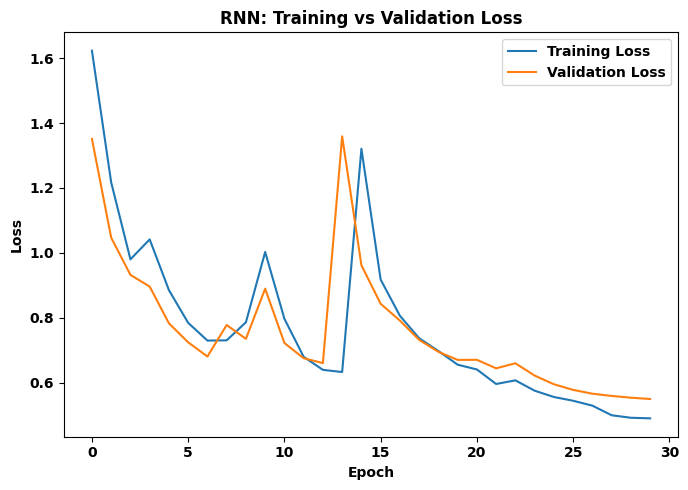

Saved: Experiment6_Plots/plot2_rnn_loss.png


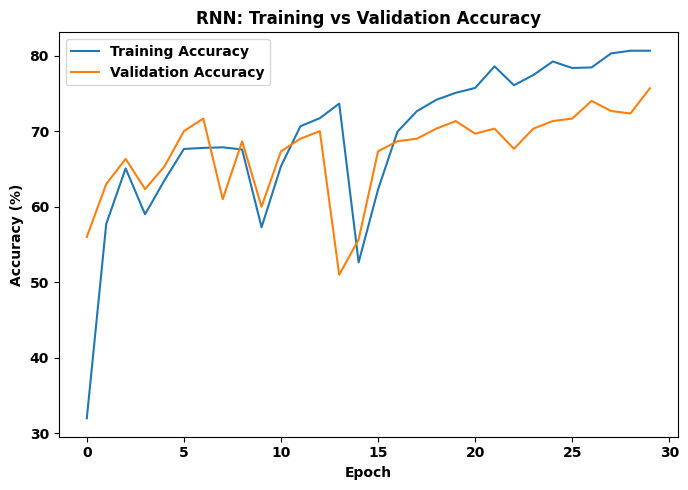

Saved: Experiment6_Plots/plot3_rnn_accuracy.png


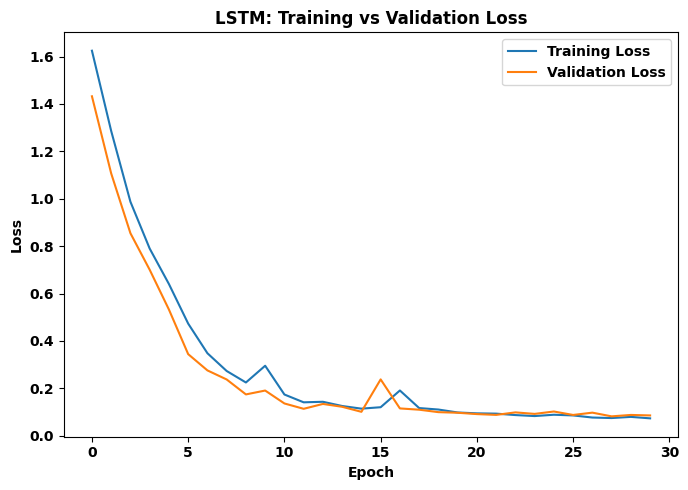

Saved: Experiment6_Plots/plot2_lstm_loss.png


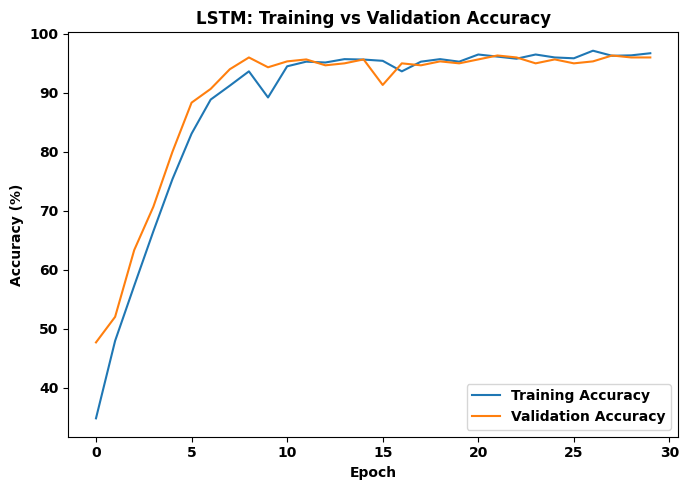

Saved: Experiment6_Plots/plot3_lstm_accuracy.png


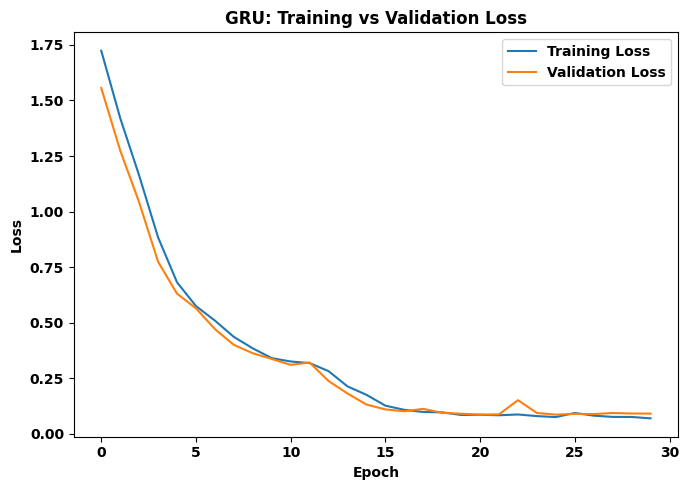

Saved: Experiment6_Plots/plot2_gru_loss.png


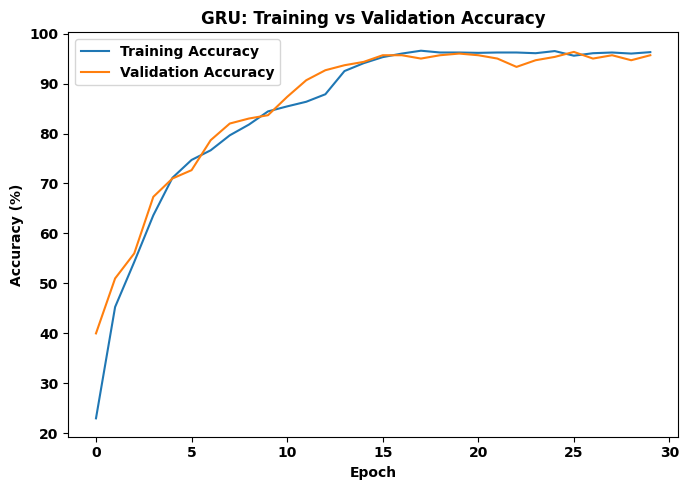

Saved: Experiment6_Plots/plot3_gru_accuracy.png


In [9]:
# ================== TASK 8: PLOTS 2 & 3 ==================
for cell in ["RNN", "LSTM", "GRU"]:
    h = histories[cell]

    plt.figure(figsize=(7, 5))
    plt.plot(h["loss"], label="Training Loss")
    plt.plot(h["val_loss"], label="Validation Loss")
    plt.xlabel("Epoch", fontweight="bold")
    plt.ylabel("Loss", fontweight="bold")
    plt.title(f"{cell}: Training vs Validation Loss", fontweight="bold")
    ax = plt.gca(); ax.legend(); style_bold_legend(ax)
    savefig(f"plot2_{cell.lower()}_loss.png")

    plt.figure(figsize=(7, 5))
    plt.plot(np.array(h["accuracy"]) * 100, label="Training Accuracy")
    plt.plot(np.array(h["val_accuracy"]) * 100, label="Validation Accuracy")
    plt.xlabel("Epoch", fontweight="bold")
    plt.ylabel("Accuracy (%)", fontweight="bold")
    plt.title(f"{cell}: Training vs Validation Accuracy", fontweight="bold")
    ax = plt.gca(); ax.legend(); style_bold_legend(ax)
    savefig(f"plot3_{cell.lower()}_accuracy.png")

In [10]:
# ================== TASK 9: TEST-SET EVALUATION ==================
results = {}
preds = {}

for cell in ["RNN", "LSTM", "GRU"]:
    m = models_dict[cell]
    y_prob = m.predict(X_test, verbose=0)
    y_pred = np.argmax(y_prob, axis=1)
    preds[cell] = y_pred

    results[cell] = {
        "Accuracy (%)": accuracy_score(y_test, y_pred) * 100,
        "Macro Precision (%)": precision_score(y_test, y_pred, average="macro") * 100,
        "Macro Recall (%)": recall_score(y_test, y_pred, average="macro") * 100,
        "Macro F1 (%)": f1_score(y_test, y_pred, average="macro") * 100,
        "Parameters": param_counts[cell],
        "Training Time (s)": train_times[cell],
    }

results_df = pd.DataFrame(results)   # rows = metrics, columns = RNN/LSTM/GRU
print("Performance Evaluation (Section 14):")
print(results_df.round(2).to_string())

Performance Evaluation (Section 14):
                         RNN     LSTM      GRU
Accuracy (%)           79.67    96.00    95.33
Macro Precision (%)    80.00    96.10    95.47
Macro Recall (%)       78.45    96.14    95.40
Macro F1 (%)           77.97    96.08    95.40
Parameters           1974.00  6006.00  4758.00
Training Time (s)      47.51    68.48    88.23


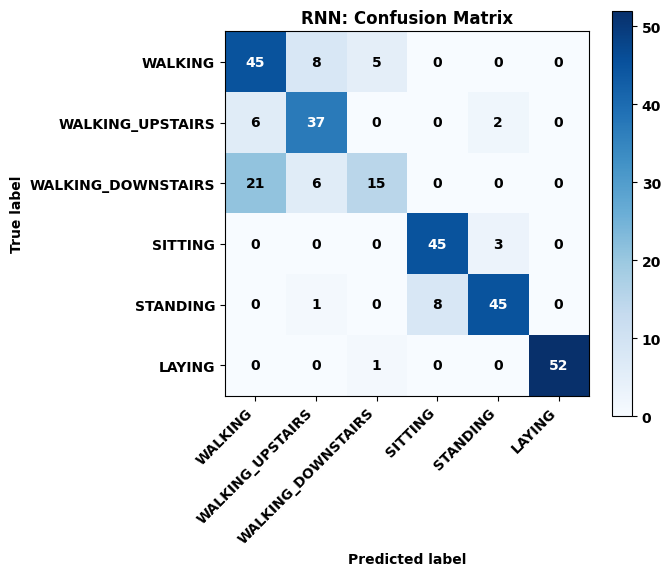

Saved: Experiment6_Plots/plot4_rnn_confusion_matrix.png


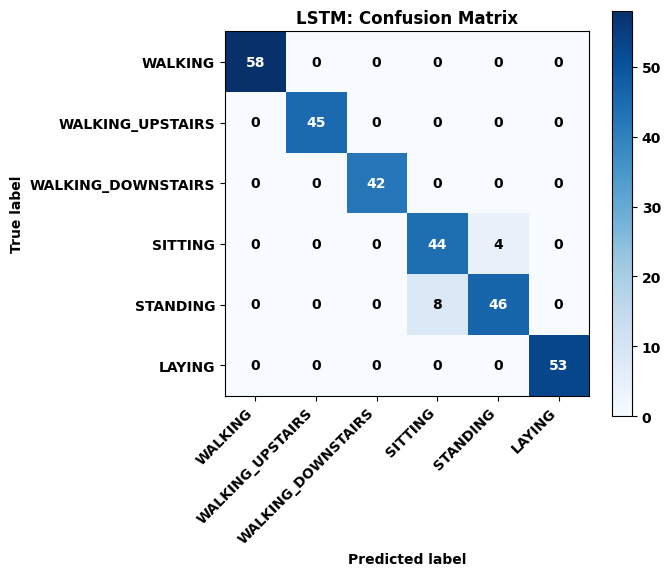

Saved: Experiment6_Plots/plot4_lstm_confusion_matrix.png


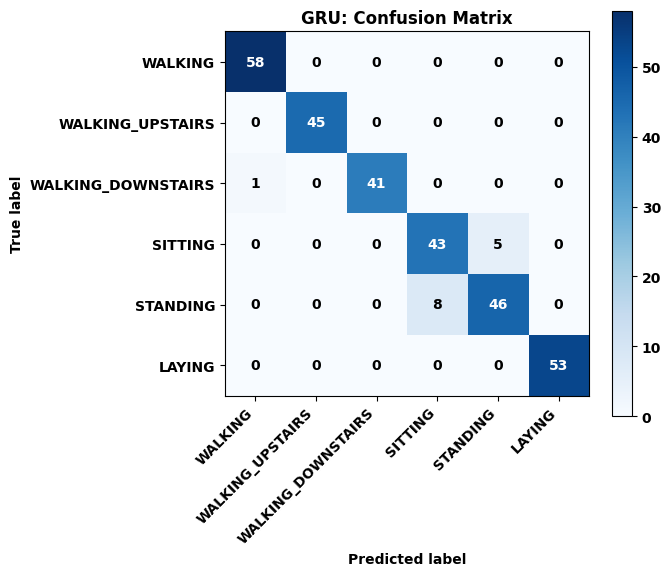

Saved: Experiment6_Plots/plot4_gru_confusion_matrix.png


In [11]:
# ================== TASK 10: PLOT 4 - CONFUSION MATRICES ==================
class_names = [ACTIVITIES[i] for i in range(1, 7)]

for cell in ["RNN", "LSTM", "GRU"]:
    cm = confusion_matrix(y_test, preds[cell])
    fig, ax = plt.subplots(figsize=(7, 6))
    im = ax.imshow(cm, cmap="Blues")
    ax.set_xticks(range(NUM_CLASSES)); ax.set_yticks(range(NUM_CLASSES))
    ax.set_xticklabels(class_names, rotation=45, ha="right", fontweight="bold")
    ax.set_yticklabels(class_names, fontweight="bold")
    ax.set_xlabel("Predicted label", fontweight="bold")
    ax.set_ylabel("True label", fontweight="bold")
    ax.set_title(f"{cell}: Confusion Matrix", fontweight="bold")
    for i in range(NUM_CLASSES):
        for j in range(NUM_CLASSES):
            ax.text(j, i, cm[i, j], ha="center", va="center",
                    color="white" if cm[i, j] > cm.max() / 2 else "black",
                    fontweight="bold")
    fig.colorbar(im, ax=ax)
    savefig(f"plot4_{cell.lower()}_confusion_matrix.png")

RNN vs LSTM vs GRU Comparison (Section 16):
                     RNN   LSTM    GRU
Hidden state         Yes    Yes    Yes
Cell state            No    Yes     No
Forget gate           No    Yes     No
Input gate            No    Yes     No
Output gate           No    Yes     No
Update gate           No     No    Yes
Reset gate            No     No    Yes
Parameters          1974   6006   4758
Training time (s)  47.51  68.48  88.23
Test F1-score (%)  77.97  96.08   95.4


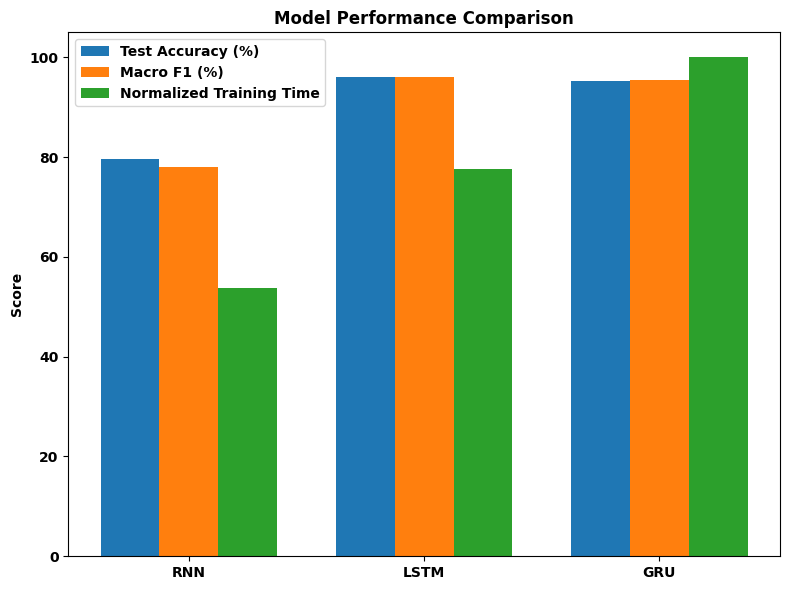

Saved: Experiment6_Plots/plot5_model_comparison.png


In [12]:
# ================== TASK 11: COMPARISON TABLE + PLOT 5 ==================
comparison_df = pd.DataFrame({
    "RNN":  {"Hidden state": "Yes", "Cell state": "No",  "Forget gate": "No",
             "Input gate": "No",  "Output gate": "No",  "Update gate": "No",
             "Reset gate": "No",
             "Parameters": param_counts["RNN"], "Training time (s)": round(train_times["RNN"], 2),
             "Test F1-score (%)": round(results["RNN"]["Macro F1 (%)"], 2)},
    "LSTM": {"Hidden state": "Yes", "Cell state": "Yes", "Forget gate": "Yes",
             "Input gate": "Yes", "Output gate": "Yes", "Update gate": "No",
             "Reset gate": "No",
             "Parameters": param_counts["LSTM"], "Training time (s)": round(train_times["LSTM"], 2),
             "Test F1-score (%)": round(results["LSTM"]["Macro F1 (%)"], 2)},
    "GRU":  {"Hidden state": "Yes", "Cell state": "No",  "Forget gate": "No",
             "Input gate": "No",  "Output gate": "No",  "Update gate": "Yes",
             "Reset gate": "Yes",
             "Parameters": param_counts["GRU"], "Training time (s)": round(train_times["GRU"], 2),
             "Test F1-score (%)": round(results["GRU"]["Macro F1 (%)"], 2)},
})
print("RNN vs LSTM vs GRU Comparison (Section 16):")
print(comparison_df.to_string())

# Bar plot: Accuracy, Macro F1, and normalized (0-100) training time
cells_order = ["RNN", "LSTM", "GRU"]
acc_vals = [results[c]["Accuracy (%)"] for c in cells_order]
f1_vals = [results[c]["Macro F1 (%)"] for c in cells_order]
time_vals = np.array([train_times[c] for c in cells_order])
time_norm = time_vals / time_vals.max() * 100

x = np.arange(len(cells_order))
width = 0.25
fig, ax = plt.subplots(figsize=(8, 6))
ax.bar(x - width, acc_vals, width, label="Test Accuracy (%)")
ax.bar(x, f1_vals, width, label="Macro F1 (%)")
ax.bar(x + width, time_norm, width, label="Normalized Training Time")
ax.set_xticks(x); ax.set_xticklabels(cells_order, fontweight="bold")
ax.set_ylabel("Score", fontweight="bold")
ax.set_title("Model Performance Comparison", fontweight="bold")
ax.legend(); style_bold_legend(ax)
savefig("plot5_model_comparison.png")

Epoch 1/15
44/44 ━━━━━━━━━━━━━━━━━━━━ 2s 13ms/step - accuracy: 0.3793 - loss: 1.5773 - val_accuracy: 0.5500 - val_loss: 1.3746
Epoch 2/15
44/44 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.5564 - loss: 1.2692 - val_accuracy: 0.6100 - val_loss: 1.1290
Epoch 3/15
44/44 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step - accuracy: 0.6143 - loss: 1.0393 - val_accuracy: 0.6767 - val_loss: 0.9536
Epoch 4/15
44/44 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step - accuracy: 0.6407 - loss: 0.8879 - val_accuracy: 0.6633 - val_loss: 0.8365
Epoch 5/15
44/44 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.6857 - loss: 0.7869 - val_accuracy: 0.6800 - val_loss: 0.7570
Epoch 6/15
44/44 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.7064 - loss: 0.7206 - val_accuracy: 0.6967 - val_loss: 0.6999
Epoch 7/15
44/44 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.7179 - loss: 0.6813 - val_accuracy: 0.7233 - val_loss: 0.6823
Epoch 8/15
44/44 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.7157 - loss: 0.6517 - val_accuracy: 0.7233 - val_loss

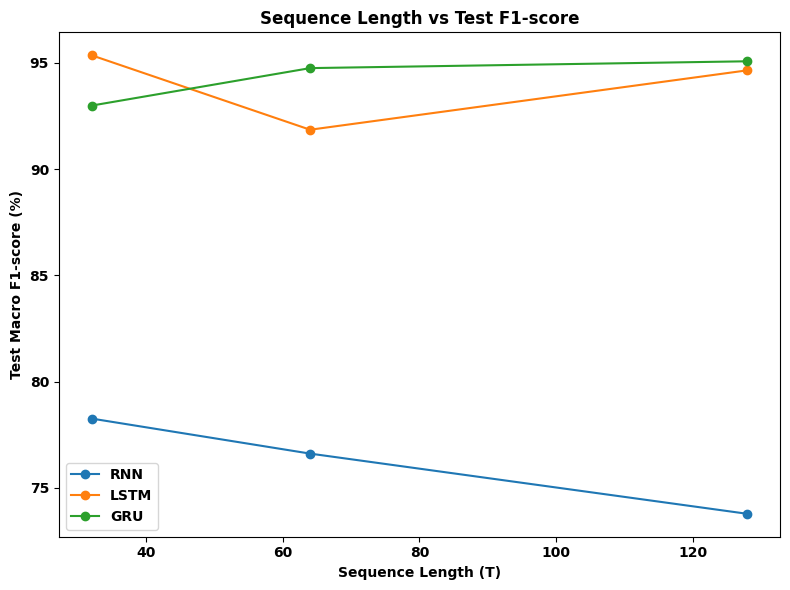

Saved: Experiment6_Plots/plot6_seqlen_vs_f1.png


In [13]:
# ================== TASK 12: SEQUENCE LENGTH EFFECT ==================
# Truncation strategy: keep the LAST T time steps of each 128-step window, applied
# identically to train/val/test and to all three models for a controlled comparison.
SEQ_EPOCHS = 15   # shorter run, purely for this length-vs-performance comparison
seq_lengths = [32, 64, 128]
seqlen_f1 = {c: [] for c in ["RNN", "LSTM", "GRU"]}

for Tlen in seq_lengths:
    Xtr_t = X_train[:, -Tlen:, :]
    Xval_t = X_val[:, -Tlen:, :]
    Xte_t = X_test[:, -Tlen:, :]
    for cell in ["RNN", "LSTM", "GRU"]:
        m = build_model(cell, T=Tlen)
        m.fit(Xtr_t, y_train, validation_data=(Xval_t, y_val),
              epochs=SEQ_EPOCHS, batch_size=BATCH, verbose=1)
        y_pred_t = np.argmax(m.predict(Xte_t, verbose=1), axis=1)
        f1_t = f1_score(y_test, y_pred_t, average="macro") * 100
        seqlen_f1[cell].append(f1_t)

seqlen_df = pd.DataFrame({
    "Sequence Length": seq_lengths,
    "RNN F1": seqlen_f1["RNN"],
    "LSTM F1": seqlen_f1["LSTM"],
    "GRU F1": seqlen_f1["GRU"],
})
print("Sequence Length vs Test F1-score (Section 17):")
print(seqlen_df.round(2).to_string(index=False))

plt.figure(figsize=(8, 6))
for cell in ["RNN", "LSTM", "GRU"]:
    plt.plot(seq_lengths, seqlen_f1[cell], marker="o", label=cell)
plt.xlabel("Sequence Length (T)", fontweight="bold")
plt.ylabel("Test Macro F1-score (%)", fontweight="bold")
plt.title("Sequence Length vs Test F1-score", fontweight="bold")
ax = plt.gca(); ax.legend(); style_bold_legend(ax)
savefig("plot6_seqlen_vs_f1.png")

In [14]:
# ================== TASK 13a: DOWNLOAD A SMALL UCF101 SUBSET ==================
!pip install -q remotezip

import remotezip as rz
import collections, pathlib, random as _random, tqdm, shutil

# Google's old thumos14_files mirror is dead (403). Using a public Hugging Face
# mirror of the official UCF101 videos instead - no login needed.
UCF_ZIP_URL = "https://huggingface.co/datasets/quchenyuan/UCF101-ZIP/resolve/main/UCF-101.zip"
CHOSEN_CLASSES = ["Basketball", "Biking", "TennisSwing"]   # pick any 3-5 UCF101 class names
VIDEOS_PER_CLASS = 15                                       # small + fast; gives room for a 70/15/15 split
VIDEO_ROOT_PATH = pathlib.Path("UCF101_subset")

if not VIDEO_ROOT_PATH.exists():
    with rz.RemoteZip(UCF_ZIP_URL) as zf:
        all_files = [f for f in (i.filename for i in zf.infolist()) if f.endswith(".avi")]

    # Files inside this zip are stored as "UCF-101/<ClassName>/<video>.avi"
    files_by_class = collections.defaultdict(list)
    for f in all_files:
        cls = pathlib.Path(f).parts[1]
        files_by_class[cls].append(f)

    with rz.RemoteZip(UCF_ZIP_URL) as zf:
        for cls in CHOSEN_CLASSES:
            _random.Random(SEED).shuffle(files_by_class[cls])
            chosen = files_by_class[cls][:VIDEOS_PER_CLASS]
            cls_dir = VIDEO_ROOT_PATH / cls
            cls_dir.mkdir(parents=True, exist_ok=True)
            print(f"Downloading {len(chosen)} videos for class '{cls}'...")
            for fn in tqdm.tqdm(chosen):
                zf.extract(fn, str(cls_dir))
                extracted = cls_dir / fn                  # cls_dir/UCF-101/ClassName/video.avi

100%|██████████| 15/15 [00:04<00:00,  3.52it/s]


100%|██████████| 15/15 [00:05<00:00,  2.90it/s]


100%|██████████| 15/15 [00:04<00:00,  3.17it/s]


In [15]:
import pathlib, shutil

def flatten_videos(cls_dir):
    cls_dir = pathlib.Path(cls_dir)
    for avi_path in cls_dir.rglob("*.avi"):
        if avi_path.parent != cls_dir:
            target = cls_dir / avi_path.name
            if not target.exists():
                avi_path.rename(target)
    for sub in sorted(cls_dir.iterdir(), reverse=True):
        if sub.is_dir():
            shutil.rmtree(sub, ignore_errors=True)

for cls in ["Basketball", "Biking", "TennisSwing"]:
    flatten_videos(f"UCF101_subset/{cls}")
    n = len(list(pathlib.Path(f"UCF101_subset/{cls}").glob("*.avi")))
    print(f"{cls}: {n} videos")

Basketball: 15 videos
Biking: 15 videos
TennisSwing: 15 videos


In [16]:
# ================== TASK 13: CNN FEATURE EXTRACTION FOR VIDEO ==================
import cv2
from tensorflow.keras.applications import MobileNetV2
from tensorflow.keras.applications.mobilenet_v2 import preprocess_input

VIDEO_ROOT = "UCF101_subset"      # <-- point this to your downloaded subset
FRAMES_PER_VIDEO = 10
IMG_SIZE = 224

cnn_extractor = MobileNetV2(weights="imagenet", include_top=False, pooling="avg")
cnn_extractor.trainable = False   # frozen feature extractor (Section 20)
FEATURE_DIM = cnn_extractor.output_shape[-1]
print("CNN feature dimension D =", FEATURE_DIM)

def sample_frames(video_path, n=FRAMES_PER_VIDEO):
    cap = cv2.VideoCapture(video_path)
    if not cap.isOpened():
        cap.release()
        return None
    frames_all = []
    while True:
        ok, frame = cap.read()
        if not ok:
            break
        frame = cv2.cvtColor(frame, cv2.COLOR_BGR2RGB)
        frame = cv2.resize(frame, (IMG_SIZE, IMG_SIZE))
        frames_all.append(frame)
    cap.release()
    if len(frames_all) == 0:
        return None
    idxs = np.linspace(0, len(frames_all) - 1, n).astype(int)
    return np.array([frames_all[i] for i in idxs])

def video_to_feature_sequence(video_path):
    frames = sample_frames(video_path)          # (10, 224, 224, 3) or None
    if frames is None:
        return None
    frames = preprocess_input(frames.astype("float32"))
    feats = cnn_extractor.predict(frames, verbose=0)   # (10, D)
    return feats

video_classes = sorted(os.listdir(VIDEO_ROOT)) if os.path.isdir(VIDEO_ROOT) else []
print("Classes found:", video_classes)

X_video, y_video, sample_frame_cache = [], [], {}
for ci, cls in enumerate(video_classes):
    cls_dir = os.path.join(VIDEO_ROOT, cls)
    for fname in os.listdir(cls_dir):
        if not fname.lower().endswith(".avi"):
            continue
        vpath = os.path.join(cls_dir, fname)
        feats = video_to_feature_sequence(vpath)
        if feats is None:
            print(f"  Skipped unreadable video: {vpath}")
            continue
        X_video.append(feats)
        y_video.append(ci)
        if cls not in sample_frame_cache:
            cached = sample_frames(vpath)
            if cached is not None:
                sample_frame_cache[cls] = cached

if X_video:
    X_video = np.array(X_video)   # (num_videos, 10, D) -- Section 19 tensor shape
    y_video = np.array(y_video)
    print("Video feature tensor shape (Section 19/20):", X_video.shape)
else:
    print("No videos found under", VIDEO_ROOT, "- set VIDEO_ROOT and re-run this cell.")

/tmp/ipykernel_680/2374400842.py:10: UserWarning: `input_shape` is undefined or non-square, or `rows` is not in [96, 128, 160, 192, 224]. Weights for input shape (224, 224) will be loaded as the default.
  cnn_extractor = MobileNetV2(weights="imagenet", include_top=False, pooling="avg")


9406464/9406464 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
CNN feature dimension D = 1280
Classes found: ['Basketball', 'Biking', 'TennisSwing']
Video feature tensor shape (Section 19/20): (45, 10, 1280)


In [17]:
!ls -la UCF101_subset/Basketball/ | head -5
!ffprobe -v error -show_format -show_streams UCF101_subset/Basketball/$(ls UCF101_subset/Basketball | head -1)

total 3940
drwxr-xr-x 2 root root   4096 Sep 23 08:12 .
drwxr-xr-x 5 root root   4096 Sep 23 08:12 ..
-rw-r--r-- 1 root root 265144 Sep 23 08:12 v_Basketball_g01_c06.avi
-rw-r--r-- 1 root root 159926 Sep 23 08:12 v_Basketball_g02_c04.avi
[STREAM]
index=0
codec_name=mpeg4
codec_long_name=MPEG-4 part 2
profile=Simple Profile
codec_type=video
codec_tag_string=xvid
codec_tag=0x64697678
width=320
height=240
coded_width=320
coded_height=240
closed_captions=0
film_grain=0
has_b_frames=0
sample_aspect_ratio=1:1
display_aspect_ratio=4:3
pix_fmt=yuv420p
level=3
color_range=unknown
color_space=unknown
color_transfer=unknown
color_primaries=unknown
chroma_location=left
field_order=unknown
refs=1
quarter_sample=false
divx_packed=false
id=N/A
r_frame_rate=30000/1001
avg_frame_rate=30000/1001
time_base=1001/30000
start_pts=0
start_time=0.000000
duration_ts=148
duration=4.938267
bit_rate=417155
max_bit_rate=N/A
bits_per_raw_sample=N/A
nb_frames=148
nb_read_frames=N/A
nb_read_packets=N/A
extradata_size


----- Training CNN-LSTM (video) -----
Epoch 1/20
8/8 - 4s - 538ms/step - accuracy: 0.5161 - loss: 1.0045 - val_accuracy: 0.8571 - val_loss: 0.7705
Epoch 2/20
8/8 - 0s - 54ms/step - accuracy: 0.9355 - loss: 0.4438 - val_accuracy: 0.8571 - val_loss: 0.6269
Epoch 3/20
8/8 - 0s - 62ms/step - accuracy: 1.0000 - loss: 0.2666 - val_accuracy: 0.5714 - val_loss: 0.6836
Epoch 4/20
8/8 - 0s - 54ms/step - accuracy: 1.0000 - loss: 0.1757 - val_accuracy: 0.7143 - val_loss: 0.6055
Epoch 5/20
8/8 - 0s - 48ms/step - accuracy: 1.0000 - loss: 0.1271 - val_accuracy: 0.7143 - val_loss: 0.4867
Epoch 6/20
8/8 - 0s - 48ms/step - accuracy: 1.0000 - loss: 0.0905 - val_accuracy: 0.7143 - val_loss: 0.5718
Epoch 7/20
8/8 - 0s - 46ms/step - accuracy: 1.0000 - loss: 0.0675 - val_accuracy: 0.7143 - val_loss: 0.5315
Epoch 8/20
8/8 - 0s - 44ms/step - accuracy: 1.0000 - loss: 0.0510 - val_accuracy: 0.7143 - val_loss: 0.5493
Epoch 9/20
8/8 - 0s - 45ms/step - accuracy: 1.0000 - loss: 0.0433 - val_accuracy: 0.7143 - val_l

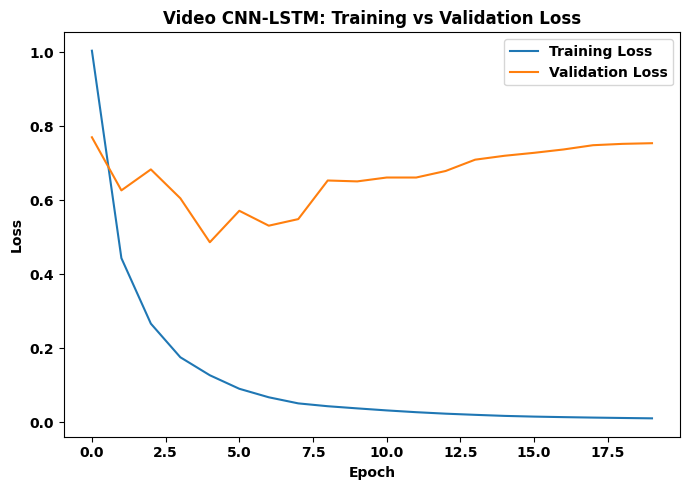

Saved: Experiment6_Plots/plot8_video_lstm_loss.png


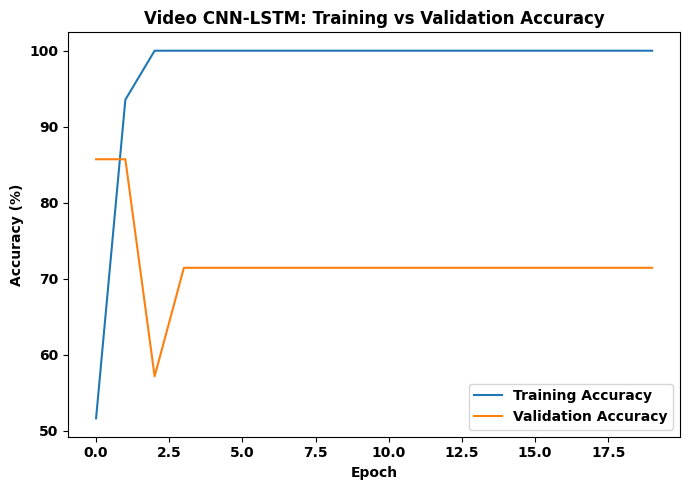

Saved: Experiment6_Plots/plot8_video_lstm_accuracy.png

----- Training CNN-GRU (video) -----
Epoch 1/20
8/8 - 5s - 653ms/step - accuracy: 0.5161 - loss: 0.9551 - val_accuracy: 0.5714 - val_loss: 0.7468
Epoch 2/20
8/8 - 0s - 55ms/step - accuracy: 0.9355 - loss: 0.2552 - val_accuracy: 0.7143 - val_loss: 0.6068
Epoch 3/20
8/8 - 1s - 69ms/step - accuracy: 1.0000 - loss: 0.0966 - val_accuracy: 0.7143 - val_loss: 0.5718
Epoch 4/20
8/8 - 0s - 49ms/step - accuracy: 1.0000 - loss: 0.0486 - val_accuracy: 0.7143 - val_loss: 0.5162
Epoch 5/20
8/8 - 1s - 80ms/step - accuracy: 1.0000 - loss: 0.0330 - val_accuracy: 0.7143 - val_loss: 0.5241
Epoch 6/20
8/8 - 0s - 52ms/step - accuracy: 1.0000 - loss: 0.0246 - val_accuracy: 0.7143 - val_loss: 0.5467
Epoch 7/20
8/8 - 1s - 70ms/step - accuracy: 1.0000 - loss: 0.0199 - val_accuracy: 0.7143 - val_loss: 0.5598
Epoch 8/20
8/8 - 1s - 66ms/step - accuracy: 1.0000 - loss: 0.0165 - val_accuracy: 0.7143 - val_loss: 0.5619
Epoch 9/20
8/8 - 0s - 55ms/step - accuracy

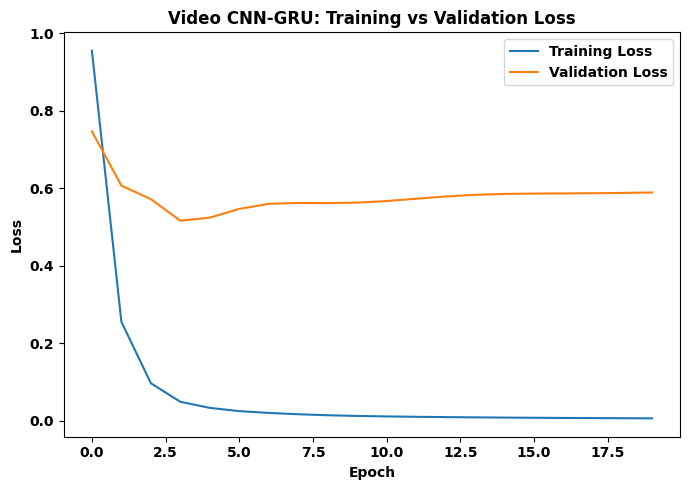

Saved: Experiment6_Plots/plot8_video_gru_loss.png


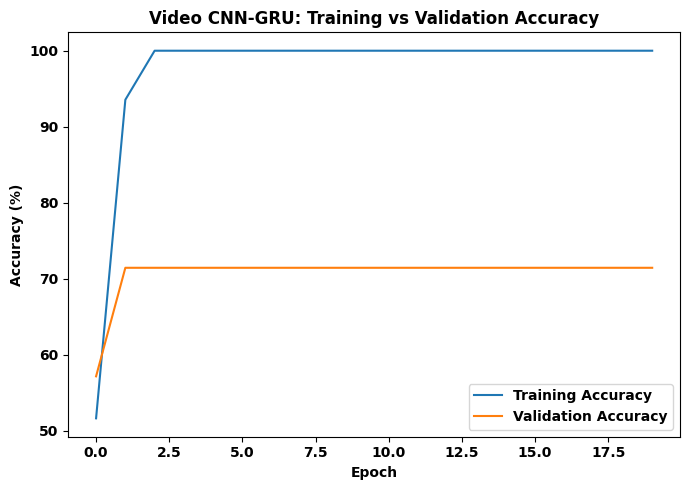

Saved: Experiment6_Plots/plot8_video_gru_accuracy.png

Video training times (s): {'LSTM': 14.036821603775024, 'GRU': 14.073427200317383}
Video parameter counts: {'LSTM': 168163, 'GRU': 126243}


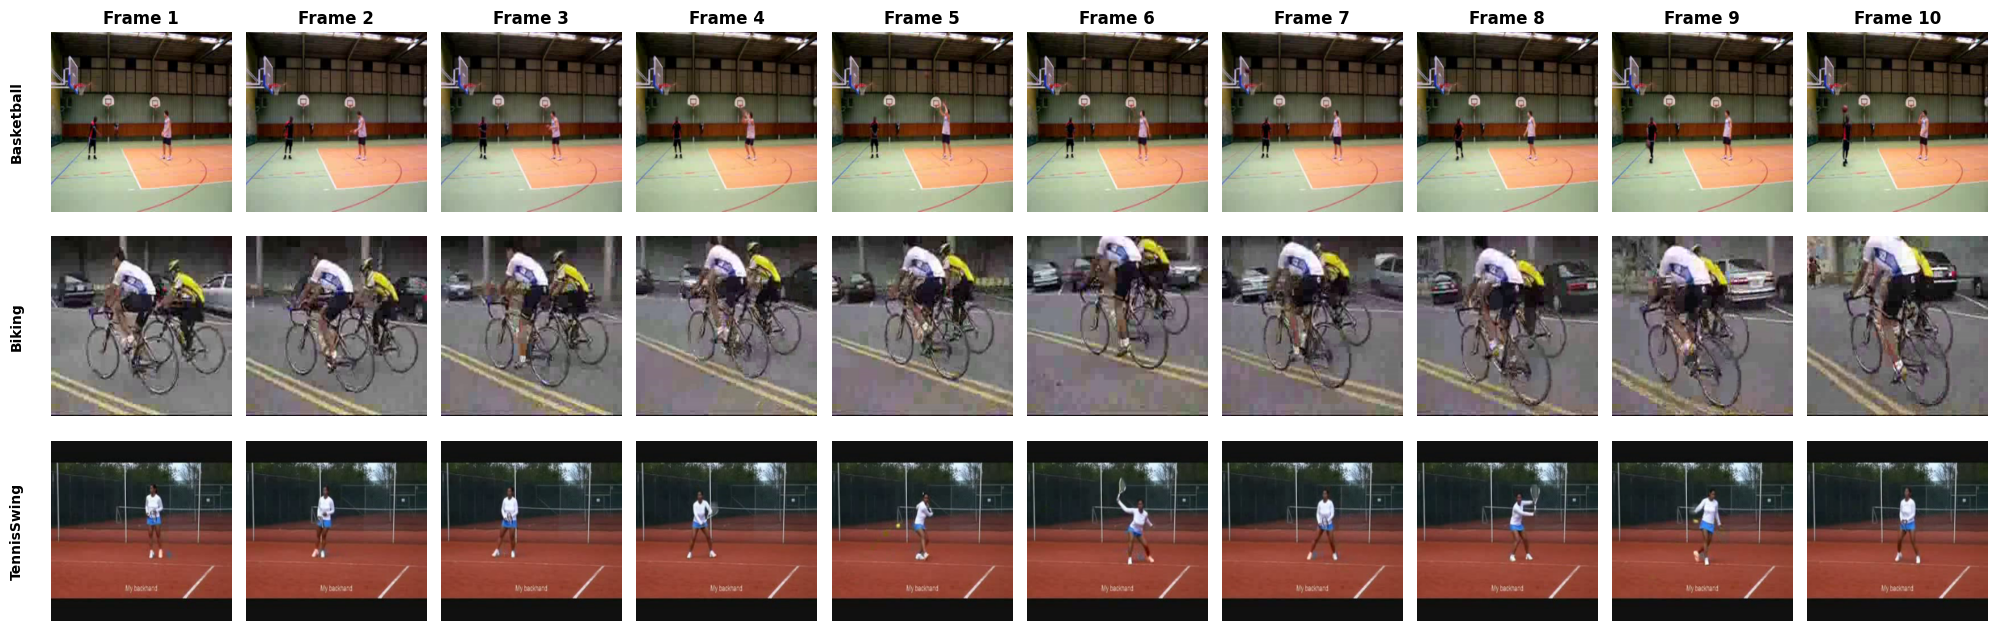

Saved: Experiment6_Plots/plot7_video_sample_frames.png


In [18]:
# ================== TASK 14: CNN-LSTM/GRU TRAINING + PLOTS 7-8 ==================
if len(X_video):
    Xv_train, Xv_tmp, yv_train, yv_tmp = train_test_split(
        X_video, y_video, test_size=0.30, stratify=y_video, random_state=SEED)
    Xv_val, Xv_test, yv_val, yv_test = train_test_split(
        Xv_tmp, yv_tmp, test_size=0.50, stratify=yv_tmp, random_state=SEED)

    def build_video_model(cell_type="LSTM"):
        rec = layers.LSTM(32) if cell_type == "LSTM" else layers.GRU(32)
        m = models.Sequential([
            layers.Input(shape=(FRAMES_PER_VIDEO, FEATURE_DIM)),
            rec,
            layers.Dense(len(video_classes), activation="softmax"),
        ])
        m.compile(optimizer=optimizers.Adam(1e-3),
                   loss="sparse_categorical_crossentropy", metrics=["accuracy"])
        return m

    # Train CNN-LSTM and CNN-GRU under identical conditions (Section 18/21)
    video_histories, video_models_dict, video_train_times, video_param_counts = {}, {}, {}, {}

    for VIDEO_CELL in ["LSTM", "GRU"]:
        print(f"\n----- Training CNN-{VIDEO_CELL} (video) -----")
        video_model = build_video_model(VIDEO_CELL)
        t0 = time.time()
        vhist = video_model.fit(Xv_train, yv_train, validation_data=(Xv_val, yv_val),
                                 epochs=20, batch_size=4, verbose=2)
        video_train_times[VIDEO_CELL] = time.time() - t0
        video_histories[VIDEO_CELL] = vhist.history
        video_models_dict[VIDEO_CELL] = video_model
        video_param_counts[VIDEO_CELL] = video_model.count_params()

        # Plot 8: training/validation loss AND accuracy (one pair per recurrent cell)
        plt.figure(figsize=(7, 5))
        plt.plot(vhist.history["loss"], label="Training Loss")
        plt.plot(vhist.history["val_loss"], label="Validation Loss")
        plt.xlabel("Epoch", fontweight="bold"); plt.ylabel("Loss", fontweight="bold")
        plt.title(f"Video CNN-{VIDEO_CELL}: Training vs Validation Loss", fontweight="bold")
        ax = plt.gca(); ax.legend(); style_bold_legend(ax)
        savefig(f"plot8_video_{VIDEO_CELL.lower()}_loss.png")

        plt.figure(figsize=(7, 5))
        plt.plot(np.array(vhist.history["accuracy"]) * 100, label="Training Accuracy")
        plt.plot(np.array(vhist.history["val_accuracy"]) * 100, label="Validation Accuracy")
        plt.xlabel("Epoch", fontweight="bold"); plt.ylabel("Accuracy (%)", fontweight="bold")
        plt.title(f"Video CNN-{VIDEO_CELL}: Training vs Validation Accuracy", fontweight="bold")
        ax = plt.gca(); ax.legend(); style_bold_legend(ax)
        savefig(f"plot8_video_{VIDEO_CELL.lower()}_accuracy.png")

    print("\nVideo training times (s):", video_train_times)
    print("Video parameter counts:", video_param_counts)

    # Plot 7: sample frames from one video per class - show every sampled frame
    # (all FRAMES_PER_VIDEO frames per class, not just the first one)
    n_cls = len(sample_frame_cache)
    n_frames_show = FRAMES_PER_VIDEO
    fig, axes = plt.subplots(n_cls, n_frames_show,
                              figsize=(2 * n_frames_show, 2.2 * n_cls))
    if n_cls == 1:
        axes = axes.reshape(1, -1)
    for row, (cls, frames) in enumerate(sample_frame_cache.items()):
        for col in range(n_frames_show):
            ax = axes[row, col]
            ax.imshow(frames[col])
            ax.axis("off")
            if row == 0:
                ax.set_title(f"Frame {col + 1}", fontweight="bold")
        axes[row, 0].text(-0.15, 0.5, cls, transform=axes[row, 0].transAxes,
                           fontweight="bold", ha="right", va="center", rotation=90)
    savefig("plot7_video_sample_frames.png")
else:
    print("Skipped: no video data loaded in the previous cell.")


CNN-LSTM -- Predicted class : Basketball
CNN-LSTM -- Actual class    : Basketball
CNN-LSTM -- Confidence      : 0.97


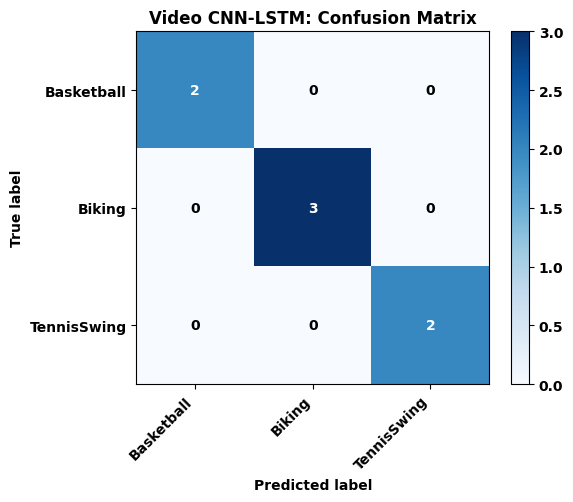

Saved: Experiment6_Plots/plot9_video_lstm_confusion_matrix.png


CNN-GRU -- Predicted class : TennisSwing
CNN-GRU -- Actual class    : Basketball
CNN-GRU -- Confidence      : 0.48


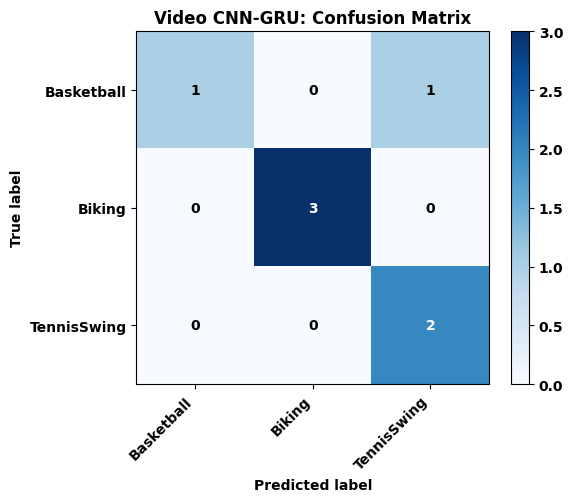

Saved: Experiment6_Plots/plot9_video_gru_confusion_matrix.png


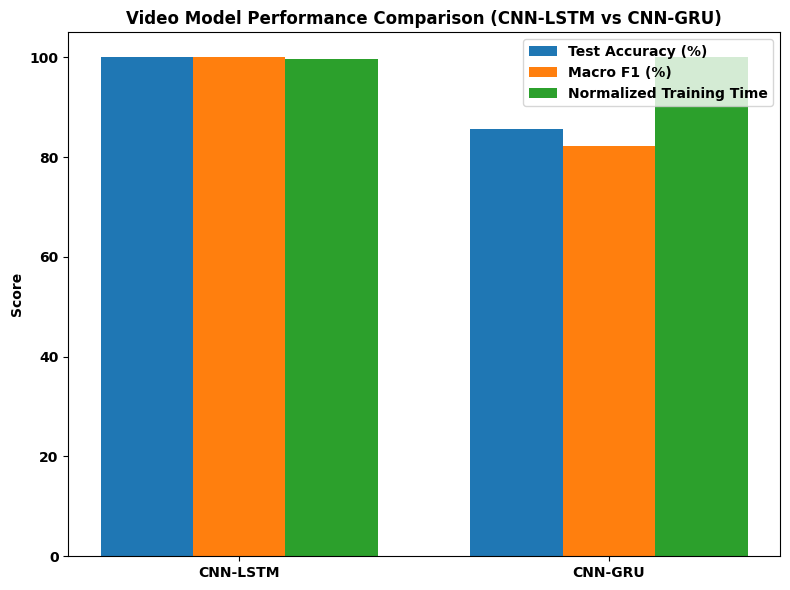

Saved: Experiment6_Plots/plot10_video_model_comparison.png


In [19]:
# ================== TASK 15: EXAMPLE PREDICTIONS + PLOT 9 (CONFUSION MATRICES) ==================
if len(X_video):
    video_results = {}
    video_preds = {}

    for VIDEO_CELL in ["LSTM", "GRU"]:
        video_model = video_models_dict[VIDEO_CELL]

        # Section 19: predicted class / actual class / confidence, read from the model
        sample_i = 0
        probs_i = video_model.predict(Xv_test[sample_i:sample_i + 1], verbose=0)[0]
        pred_i = np.argmax(probs_i)
        print(f"CNN-{VIDEO_CELL} -- Predicted class : {video_classes[pred_i]}")
        print(f"CNN-{VIDEO_CELL} -- Actual class    : {video_classes[yv_test[sample_i]]}")
        print(f"CNN-{VIDEO_CELL} -- Confidence      : {probs_i[pred_i]:.2f}")

        yv_pred = np.argmax(video_model.predict(Xv_test, verbose=0), axis=1)
        video_preds[VIDEO_CELL] = yv_pred
        video_results[VIDEO_CELL] = {
            "Accuracy (%)": accuracy_score(yv_test, yv_pred) * 100,
            "Macro F1 (%)": f1_score(yv_test, yv_pred, average="macro") * 100,
        }

        # Plot 9: video confusion matrix (one per recurrent cell)
        cm_v = confusion_matrix(yv_test, yv_pred)
        fig, ax = plt.subplots(figsize=(6, 5))
        im = ax.imshow(cm_v, cmap="Blues")
        ax.set_xticks(range(len(video_classes))); ax.set_yticks(range(len(video_classes)))
        ax.set_xticklabels(video_classes, rotation=45, ha="right", fontweight="bold")
        ax.set_yticklabels(video_classes, fontweight="bold")
        ax.set_xlabel("Predicted label", fontweight="bold")
        ax.set_ylabel("True label", fontweight="bold")
        ax.set_title(f"Video CNN-{VIDEO_CELL}: Confusion Matrix", fontweight="bold")
        for i in range(len(video_classes)):
            for j in range(len(video_classes)):
                ax.text(j, i, cm_v[i, j], ha="center", va="center", fontweight="bold",
                         color="white" if cm_v[i, j] > cm_v.max() / 2 else "black")
        fig.colorbar(im, ax=ax)
        savefig(f"plot9_video_{VIDEO_CELL.lower()}_confusion_matrix.png")

    # Plot 10: CNN-LSTM vs CNN-GRU comparison (accuracy, macro F1, normalized training time)
    v_cells_order = ["LSTM", "GRU"]
    v_acc_vals = [video_results[c]["Accuracy (%)"] for c in v_cells_order]
    v_f1_vals = [video_results[c]["Macro F1 (%)"] for c in v_cells_order]
    v_time_vals = np.array([video_train_times[c] for c in v_cells_order])
    v_time_norm = v_time_vals / v_time_vals.max() * 100

    x = np.arange(len(v_cells_order))
    width = 0.25
    fig, ax = plt.subplots(figsize=(8, 6))
    ax.bar(x - width, v_acc_vals, width, label="Test Accuracy (%)")
    ax.bar(x, v_f1_vals, width, label="Macro F1 (%)")
    ax.bar(x + width, v_time_norm, width, label="Normalized Training Time")
    ax.set_xticks(x); ax.set_xticklabels([f"CNN-{c}" for c in v_cells_order], fontweight="bold")
    ax.set_ylabel("Score", fontweight="bold")
    ax.set_title("Video Model Performance Comparison (CNN-LSTM vs CNN-GRU)", fontweight="bold")
    ax.legend(); style_bold_legend(ax)
    savefig("plot10_video_model_comparison.png")
else:
    print("Skipped: no video data loaded.")


In [20]:
# ================== TASK 16: SEQ2SEQ - DATA + ENCODER-DECODER MODEL ==================
VOCAB_MIN, VOCAB_MAX = 0, 9
SEQ_LEN = 4
NUM_SAMPLES = 5000
PAD_TOKEN = 10          # extra symbol used as the decoder start token
VOCAB_SIZE = VOCAB_MAX + 2   # digits 0-9 plus start token

rng = np.random.default_rng(SEED)
seqs = rng.integers(VOCAB_MIN, VOCAB_MAX + 1, size=(NUM_SAMPLES, SEQ_LEN))
targets = seqs[:, ::-1]   # reversal task, e.g. [1,4,7,2] -> [2,7,4,1]

# Decoder input = start token followed by target shifted right (teacher forcing)
decoder_input = np.concatenate(
    [np.full((NUM_SAMPLES, 1), PAD_TOKEN), targets[:, :-1]], axis=1)

Xs_train, Xs_test, Xd_train, Xd_test, y_train_seq, y_test_seq = train_test_split(
    seqs, decoder_input, targets, test_size=0.2, random_state=SEED)
Xs_train, Xs_val, Xd_train, Xd_val, y_train_seq, y_val_seq = train_test_split(
    Xs_train, Xd_train, y_train_seq, test_size=0.1, random_state=SEED)

EMB_DIM, ENC_UNITS = 16, 32

enc_inputs = layers.Input(shape=(SEQ_LEN,), name="encoder_input")
enc_emb = layers.Embedding(VOCAB_SIZE, EMB_DIM)(enc_inputs)
_, state_h, state_c = layers.LSTM(ENC_UNITS, return_state=True)(enc_emb)   # encoder -> context

dec_inputs = layers.Input(shape=(SEQ_LEN,), name="decoder_input")
dec_emb = layers.Embedding(VOCAB_SIZE, EMB_DIM)(dec_inputs)
dec_lstm_out = layers.LSTM(ENC_UNITS, return_sequences=True)(
    dec_emb, initial_state=[state_h, state_c])                             # decoder
dec_outputs = layers.Dense(VOCAB_SIZE, activation="softmax")(dec_lstm_out)

seq2seq_model = models.Model([enc_inputs, dec_inputs], dec_outputs)
seq2seq_model.compile(optimizer=optimizers.Adam(1e-3),
                       loss="sparse_categorical_crossentropy", metrics=["accuracy"])
seq2seq_model.summary()

seq_hist = seq2seq_model.fit(
    [Xs_train, Xd_train], y_train_seq,
    validation_data=([Xs_val, Xd_val], y_val_seq),
    epochs=30, batch_size=64, verbose=2)

Model: "functional_15"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ encoder_input       │ (None, 4)         │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ decoder_input       │ (None, 4)         │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ embedding           │ (None, 4, 16)     │        176 │ encoder_input[0]… │
│ (Embedding)         │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ embedding_1         │ (None, 4, 16)     │        176 │ decoder_input[0]… │
│ (Embedding)         │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ lstm_6 (LSTM)       │ [(None, 32),      │      6,272 │ embedding[0][0]   │
│                     │ (None, 32),       │            │                   │
│                     │ (None, 32)]       │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ lstm_7 (LSTM)       │ (None, 4, 32)     │      6,272 │ embedding_1[0][0… │
│                     │                   │            │ lstm_6[0][1],     │
│                     │                   │            │ lstm_6[0][2]      │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_28 (Dense)    │ (None, 4, 11)     │        363 │ lstm_7[0][0]      │
└─────────────────────┴───────────────────┴────────────┴───────────────────┘

 Total params: 13,259 (51.79 KB)

 Trainable params: 13,259 (51.79 KB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/30
57/57 - 3s - 56ms/step - accuracy: 0.2332 - loss: 2.3234 - val_accuracy: 0.2200 - val_loss: 2.1586
Epoch 2/30
57/57 - 1s - 14ms/step - accuracy: 0.3042 - loss: 1.9340 - val_accuracy: 0.3369 - val_loss: 1.7911
Epoch 3/30
57/57 - 1s - 14ms/step - accuracy: 0.4271 - loss: 1.5626 - val_accuracy: 0.5125 - val_loss: 1.3236
Epoch 4/30
57/57 - 1s - 15ms/step - accuracy: 0.6151 - loss: 1.0948 - val_accuracy: 0.7281 - val_loss: 0.8702
Epoch 5/30
57/57 - 1s - 14ms/step - accuracy: 0.8152 - loss: 0.7139 - val_accuracy: 0.8806 - val_loss: 0.5771
Epoch 6/30
57/57 - 0s - 7ms/step - accuracy: 0.9177 - loss: 0.4794 - val_accuracy: 0.9438 - val_loss: 0.3985
Epoch 7/30
57/57 - 0s - 8ms/step - accuracy: 0.9644 - loss: 0.3394 - val_accuracy: 0.9725 - val_loss: 0.2902
Epoch 8/30
57/57 - 0s - 8ms/step - accuracy: 0.9819 - loss: 0.2525 - val_accuracy: 0.9819 - val_loss: 0.2216
Epoch 9/30
57/57 - 0s - 8ms/step - accuracy: 0.9910 - loss: 0.1950 - val_accuracy: 0.9906 - val_loss: 0.1750
Epoch 10/30
57

In [21]:
# ================== TASK 17: SEQ2SEQ EVALUATION ==================
def greedy_decode(model, input_seq, seq_len=SEQ_LEN, start_token=PAD_TOKEN):
    dec_in = np.full((input_seq.shape[0], seq_len), start_token)
    output = np.zeros((input_seq.shape[0], seq_len), dtype=int)
    for t in range(seq_len):
        probs = model.predict([input_seq, dec_in], verbose=0)
        step_pred = np.argmax(probs[:, t, :], axis=-1)
        output[:, t] = step_pred
        if t + 1 < seq_len:
            dec_in[:, t + 1] = step_pred
    return output

y_pred_seq = greedy_decode(seq2seq_model, Xs_test)

token_acc = np.mean(y_pred_seq == y_test_seq)
seq_acc = np.mean(np.all(y_pred_seq == y_test_seq, axis=1))
seq2seq_final_train_loss = seq_hist.history["loss"][-1]
seq2seq_final_val_loss = seq_hist.history["val_loss"][-1]

print(f"Token accuracy:    {token_acc * 100:.2f}%")
print(f"Sequence accuracy: {seq_acc * 100:.2f}%")
print(f"Final training loss:   {seq2seq_final_train_loss:.4f}")
print(f"Final validation loss: {seq2seq_final_val_loss:.4f}")

# Section 23: display at least 5 test examples
print("\nSample Input Sequence -> Predicted Output (Section 23):")
seq2seq_examples = pd.DataFrame({
    "Sample": range(1, 6),
    "Input Sequence": [Xs_test[i].tolist() for i in range(5)],
    "Predicted Output": [y_pred_seq[i].tolist() for i in range(5)],
    "Actual Output": [y_test_seq[i].tolist() for i in range(5)],
})
print(seq2seq_examples.to_string(index=False))

Token accuracy:    100.00%
Sequence accuracy: 100.00%
Final training loss:   0.0150
Final validation loss: 0.0159

Sample Input Sequence -> Predicted Output (Section 23):
 Sample Input Sequence Predicted Output Actual Output
      1   [4, 2, 2, 7]     [7, 2, 2, 4]  [7, 2, 2, 4]
      2   [7, 8, 9, 0]     [0, 9, 8, 7]  [0, 9, 8, 7]
      3   [0, 9, 5, 2]     [2, 5, 9, 0]  [2, 5, 9, 0]
      4   [1, 5, 8, 5]     [5, 8, 5, 1]  [5, 8, 5, 1]
      5   [5, 8, 1, 9]     [9, 1, 8, 5]  [9, 1, 8, 5]


In [22]:
# ================== TASK 18: CONSOLIDATED RESULTS ==================
consolidated = {c: {
    "Accuracy": round(results[c]["Accuracy (%)"], 2),
    "Precision": round(results[c]["Macro Precision (%)"], 2),
    "Recall": round(results[c]["Macro Recall (%)"], 2),
    "F1": round(results[c]["Macro F1 (%)"], 2),
    "Parameters": param_counts[c],
} for c in ["RNN", "LSTM", "GRU"]}

if len(X_video):
    for VIDEO_CELL in ["LSTM", "GRU"]:
        yv_pred_final = video_preds[VIDEO_CELL]
        consolidated[f"CNN-{VIDEO_CELL}"] = {
            "Accuracy": round(accuracy_score(yv_test, yv_pred_final) * 100, 2),
            "Precision": round(precision_score(yv_test, yv_pred_final, average="macro") * 100, 2),
            "Recall": round(recall_score(yv_test, yv_pred_final, average="macro") * 100, 2),
            "F1": round(f1_score(yv_test, yv_pred_final, average="macro") * 100, 2),
            "Parameters": video_models_dict[VIDEO_CELL].count_params(),
        }

consolidated_df = pd.DataFrame(consolidated).T
print("Consolidated Results — Sequence & Video Models (Section 25):")
print(consolidated_df.to_string())

seq2seq_table = pd.DataFrame({
    "Metric": ["Token Accuracy (%)", "Sequence Accuracy (%)",
               "Final Training Loss", "Final Validation Loss"],
    "Value": [round(token_acc * 100, 2), round(seq_acc * 100, 2),
              round(seq2seq_final_train_loss, 4), round(seq2seq_final_val_loss, 4)],
})
print("\nConsolidated Results — Seq2Seq Task (Section 25, separate table):")
print(seq2seq_table.to_string(index=False))

print(f"\nAll plots saved under: {os.path.abspath(PLOT_DIR)}")


Consolidated Results — Sequence & Video Models (Section 25):
          Accuracy  Precision  Recall      F1  Parameters
RNN          79.67      80.00   78.45   77.97      1974.0
LSTM         96.00      96.10   96.14   96.08      6006.0
GRU          95.33      95.47   95.40   95.40      4758.0
CNN-LSTM    100.00     100.00  100.00  100.00    168163.0
CNN-GRU      85.71      88.89   83.33   82.22    126243.0

Consolidated Results — Seq2Seq Task (Section 25, separate table):
               Metric    Value
   Token Accuracy (%) 100.0000
Sequence Accuracy (%) 100.0000
  Final Training Loss   0.0150
Final Validation Loss   0.0159

All plots saved under: /content/Experiment6_Plots


In [23]:
# ================== TASK 19 (OPTIONAL BONUS): UNITS 16 vs 32 vs 64 ==================
# Exercise 1: replace the 32 recurrent units with 16 and 64, compare accuracy/F1/
# parameter count/training time. Uses the same build_model() from Task 6.
bonus_units_results = []
for units in [16, 32, 64]:
    m = build_model("LSTM", units=units)
    t0 = time.time()
    m.fit(X_train, y_train, validation_data=(X_val, y_val),
          epochs=15, batch_size=BATCH, verbose=1)
    dt = time.time() - t0
    y_pred_u = np.argmax(m.predict(X_test, verbose=1), axis=1)
    bonus_units_results.append({
        "Units": units,
        "Accuracy (%)": round(accuracy_score(y_test, y_pred_u) * 100, 2),
        "Macro F1 (%)": round(f1_score(y_test, y_pred_u, average="macro") * 100, 2),
        "Parameters": m.count_params(),
        "Training Time (s)": round(dt, 2),
    })

print("LSTM units comparison (Exercise 1):")
print(pd.DataFrame(bonus_units_results).to_string(index=False))

# Exercise 4 (quick variant): bidirectional vs unidirectional LSTM, same units
def build_bidir_lstm(units=32, T=T, F=F, num_classes=NUM_CLASSES):
    m = models.Sequential([
        layers.Input(shape=(T, F)),
        layers.Bidirectional(layers.LSTM(units)),
        layers.Dropout(0.2),
        layers.Dense(16, activation="relu"),
        layers.Dense(num_classes, activation="softmax"),
    ])
    m.compile(optimizer=optimizers.Adam(1e-3),
              loss="sparse_categorical_crossentropy", metrics=["accuracy"])
    return m

bidir_model = build_bidir_lstm()
bidir_model.fit(X_train, y_train, validation_data=(X_val, y_val),
                epochs=15, batch_size=BATCH, verbose=1)
y_pred_bi = np.argmax(bidir_model.predict(X_test, verbose=1), axis=1)
print(f"\nBidirectional LSTM  -> Accuracy: {accuracy_score(y_test, y_pred_bi) * 100:.2f}%, "
      f"Macro F1: {f1_score(y_test, y_pred_bi, average='macro') * 100:.2f}%, "
      f"Params: {bidir_model.count_params()}")
print(f"Unidirectional LSTM -> Accuracy: {results['LSTM']['Accuracy (%)']:.2f}%, "
      f"Macro F1: {results['LSTM']['Macro F1 (%)']:.2f}%, Params: {param_counts['LSTM']}")
# ================== TASK 20 (OPTIONAL BONUS): EXERCISES 2, 3, 5, 6, 7 ==================

# ---- Exercise 2: GRU vs LSTM, same units (32, already trained in Task 7) ----
print("Exercise 2: GRU vs LSTM at same units (32) [reusing Task 7 results]")
print(f"LSTM -> Accuracy: {results['LSTM']['Accuracy (%)']:.2f}%, "
      f"Macro F1: {results['LSTM']['Macro F1 (%)']:.2f}%, Params: {param_counts['LSTM']}, "
      f"Time: {train_times['LSTM']:.2f}s")
print(f"GRU  -> Accuracy: {results['GRU']['Accuracy (%)']:.2f}%, "
      f"Macro F1: {results['GRU']['Macro F1 (%)']:.2f}%, Params: {param_counts['GRU']}, "
      f"Time: {train_times['GRU']:.2f}s")

# ---- Exercise 3: second recurrent layer - does performance improve? ----
def build_stacked_lstm(units=32, T=T, F=F, num_classes=NUM_CLASSES):
    m = models.Sequential([
        layers.Input(shape=(T, F)),
        layers.LSTM(units, return_sequences=True),
        layers.LSTM(units),
        layers.Dropout(0.2),
        layers.Dense(16, activation="relu"),
        layers.Dense(num_classes, activation="softmax"),
    ])
    m.compile(optimizer=optimizers.Adam(1e-3),
              loss="sparse_categorical_crossentropy", metrics=["accuracy"])
    return m

stacked_model = build_stacked_lstm()
t0 = time.time()
stacked_model.fit(X_train, y_train, validation_data=(X_val, y_val),
                   epochs=15, batch_size=BATCH, verbose=1)
dt_stacked = time.time() - t0
y_pred_stacked = np.argmax(stacked_model.predict(X_test, verbose=1), axis=1)

print("\nExercise 3: single-layer vs stacked (2-layer) LSTM")
print(f"Single-layer LSTM -> Accuracy: {results['LSTM']['Accuracy (%)']:.2f}%, "
      f"Macro F1: {results['LSTM']['Macro F1 (%)']:.2f}%, Params: {param_counts['LSTM']}")
print(f"Stacked LSTM       -> Accuracy: {accuracy_score(y_test, y_pred_stacked) * 100:.2f}%, "
      f"Macro F1: {f1_score(y_test, y_pred_stacked, average='macro') * 100:.2f}%, "
      f"Params: {stacked_model.count_params()}, Time: {dt_stacked:.2f}s")

# ---- Exercise 5: sequence length vs computational cost (training time) ----
seqlen_time = {c: [] for c in ["RNN", "LSTM", "GRU"]}
for Tlen in seq_lengths:              # reuses seq_lengths = [32, 64, 128] from Task 12
    Xtr_t = X_train[:, -Tlen:, :]
    Xval_t = X_val[:, -Tlen:, :]
    for cell in ["RNN", "LSTM", "GRU"]:
        m = build_model(cell, T=Tlen)
        t0 = time.time()
        m.fit(Xtr_t, y_train, validation_data=(Xval_t, y_val),
              epochs=SEQ_EPOCHS, batch_size=BATCH, verbose=1)
        seqlen_time[cell].append(time.time() - t0)

print("\nExercise 5: Sequence length vs training time (s)")
print(pd.DataFrame({"Sequence Length": seq_lengths,
                     **{f"{c} Time": seqlen_time[c] for c in ["RNN", "LSTM", "GRU"]}}
                    ).round(2).to_string(index=False))

# ---- Exercise 6: video - LSTM vs GRU on identical CNN features ----
if len(X_video):
    gru_video_model = build_video_model("GRU")   # reuses X_video/y_video from Task 13/14
    gru_video_model.fit(Xv_train, yv_train, validation_data=(Xv_val, yv_val),
                         epochs=20, batch_size=4, verbose=1)
    yv_pred_gru = np.argmax(gru_video_model.predict(Xv_test, verbose=1), axis=1)

    print("\nExercise 6: Video CNN-LSTM vs CNN-GRU on identical CNN features")

    lstm_video_pred = video_preds["LSTM"]

    print(f"CNN-LSTM -> Accuracy: {accuracy_score(yv_test, lstm_video_pred) * 100:.2f}%, "
          f"Macro F1: {f1_score(yv_test, lstm_video_pred, average='macro') * 100:.2f}%")

    print(f"CNN-GRU  -> Accuracy: {accuracy_score(yv_test, yv_pred_gru) * 100:.2f}%, "
          f"Macro F1: {f1_score(yv_test, yv_pred_gru, average='macro') * 100:.2f}%")
else:
    print("\nExercise 6 skipped: no video data loaded.")

# ---- Exercise 7: seq2seq with output length != input length ----
SEQ_LEN_IN, SEQ_LEN_OUT = 6, 3   # output shorter than input this time

seqs7 = rng.integers(VOCAB_MIN, VOCAB_MAX + 1, size=(NUM_SAMPLES, SEQ_LEN_IN))
targets7 = seqs7[:, :SEQ_LEN_OUT][:, ::-1]   # reverse only the first 3 elements

dec_input7 = np.concatenate(
    [np.full((NUM_SAMPLES, 1), PAD_TOKEN), targets7[:, :-1]], axis=1)

Xs7_train, Xs7_test, Xd7_train, Xd7_test, y7_train, y7_test = train_test_split(
    seqs7, dec_input7, targets7, test_size=0.2, random_state=SEED)

enc_in7 = layers.Input(shape=(SEQ_LEN_IN,))
enc_emb7 = layers.Embedding(VOCAB_SIZE, EMB_DIM)(enc_in7)
_, sh7, sc7 = layers.LSTM(ENC_UNITS, return_state=True)(enc_emb7)

dec_in7 = layers.Input(shape=(SEQ_LEN_OUT,))
dec_emb7 = layers.Embedding(VOCAB_SIZE, EMB_DIM)(dec_in7)
dec_out7 = layers.LSTM(ENC_UNITS, return_sequences=True)(dec_emb7, initial_state=[sh7, sc7])
dec_out7 = layers.Dense(VOCAB_SIZE, activation="softmax")(dec_out7)

model7 = models.Model([enc_in7, dec_in7], dec_out7)
model7.compile(optimizer=optimizers.Adam(1e-3), loss="sparse_categorical_crossentropy", metrics=["accuracy"])
model7.fit([Xs7_train, Xd7_train], y7_train, epochs=20, batch_size=64, verbose=1)

y_pred7 = greedy_decode(model7, Xs7_test, seq_len=SEQ_LEN_OUT)
print(f"\nExercise 7: seq2seq with input length {SEQ_LEN_IN} -> output length {SEQ_LEN_OUT}")
print(f"Token accuracy: {np.mean(y_pred7 == y7_test) * 100:.2f}%")
print(f"Sequence accuracy: {np.mean(np.all(y_pred7 == y7_test, axis=1)) * 100:.2f}%")

Epoch 1/15
44/44 ━━━━━━━━━━━━━━━━━━━━ 3s 43ms/step - accuracy: 0.2929 - loss: 1.7065 - val_accuracy: 0.4233 - val_loss: 1.5817
Epoch 2/15
44/44 ━━━━━━━━━━━━━━━━━━━━ 2s 37ms/step - accuracy: 0.4479 - loss: 1.4920 - val_accuracy: 0.4567 - val_loss: 1.3836
Epoch 3/15
44/44 ━━━━━━━━━━━━━━━━━━━━ 2s 37ms/step - accuracy: 0.5007 - loss: 1.3264 - val_accuracy: 0.5233 - val_loss: 1.2505
Epoch 4/15
44/44 ━━━━━━━━━━━━━━━━━━━━ 2s 46ms/step - accuracy: 0.5871 - loss: 1.1609 - val_accuracy: 0.6467 - val_loss: 1.0406
Epoch 5/15
44/44 ━━━━━━━━━━━━━━━━━━━━ 3s 61ms/step - accuracy: 0.6650 - loss: 0.9251 - val_accuracy: 0.6967 - val_loss: 0.8179
Epoch 6/15
44/44 ━━━━━━━━━━━━━━━━━━━━ 2s 38ms/step - accuracy: 0.7100 - loss: 0.7555 - val_accuracy: 0.7033 - val_loss: 0.7117
Epoch 7/15
44/44 ━━━━━━━━━━━━━━━━━━━━ 2s 37ms/step - accuracy: 0.7400 - loss: 0.6825 - val_accuracy: 0.7267 - val_loss: 0.6716
Epoch 8/15
44/44 ━━━━━━━━━━━━━━━━━━━━ 2s 37ms/step - accuracy: 0.7293 - loss: 0.6445 - val_accuracy: 0.7167 - v